In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
# pip install stepmix

In [4]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [5]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'serum ketones', 'Theophylline', 'Pressure Control', 'Vent Other',
       'WBC's in peritoneal fluid', 'Cyclosporin', 'Site', 'Amikacin - peak',
       'PTT ratio', 'Vancomycin - peak'],
      dtype='object', length=228)

In [6]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [7]:
myXValue = myPredictorsDf.drop(columns= ['GCS Total', 'LastMGCSTime', 'FirstMGCSTime', 'Motor', 'LastMGCSPositive', 'LastMGCS', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastGCS15', 'Hypothermia']], test_size=0.3)

In [8]:
# from mlxtend.feature_selection import SequentialFeatureSelector as SFS
# myPipelineSteps = getDefaultPipelineSteps(X_train)
# myPipeline = Pipeline(myPipelineSteps)
# X_train_transf = myPipeline.fit_transform(X_train)
# sfs = SFS(LogisticRegressionClassifier(), 
#           k_features=20,  # Can specify exact number or 'best' for optimal selection
#           forward=True, 
#           floating=False, 
#           scoring='accuracy', 
#           cv=3,
#          n_jobs=-1)
# sfs.fit(X_train_transf, y_train)

In [9]:
# Get selected feature indices
# selected_features = sfs.k_feature_idx_
# print("Selected Features:", myPipeline.get_feature_names_out()[selected_features])
# print(f'SFS accuracy {}')

In [31]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myXValue = myPredictorsDf.drop(columns= ['GCS Total', 'LastMGCSTime', 'FirstMGCSTime', 'Motor', 'LastMGCSPositive', 'LastMGCS', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myXValue.FirstMGCS = myXValue.FirstMGCS.astype(int)
myNewXValue = myXValue.copy()
myNewXValue = myNewXValue.drop(columns=['gender'])
myYValue = myPredictorsDf[myFilter]['DeathAtDischarge']
myYValue = myYValue.astype(int)
X_train_no_group, X_test_no_group, T_train, T_test, Y_train, Y_test = train_test_split(myNewXValue, myPredictorsDf[myFilter]['gender'], myYValue, test_size=0.3, stratify=myPredictorsDf[myFilter][['LastMGCSPositive', 'Hypothermia']])
causal_forest = CausalForestDML(
    # model_t=LogisticRegression(),    # Model to predict treatment
    # model_y=LogisticRegression(),    # Model to predict outcome
    # n_estimators=100,                   # Number of trees in the forest
    # min_samples_leaf=10,
    # max_depth=10,
    discrete_treatment=True,            # Indicate binary treatment
    discrete_outcome=True,
    # inference = True,
    # criterion="het"
)
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', SimpleImputer(missing_values=np.nan, strategy='median'))]#, ('pca', PCA(n_components=0.95))]
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group))
# myNewXTrain.columns = X_train_no_group.columns
causal_forest.fit(Y_train, T_train, X=myNewXTrain, cache_values=False)
print(causal_forest.score(Y_train, T_train, X=myNewXTrain))

myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group))
myNewXTrain.columns = X_train_no_group.columns
CATE_pred = causal_forest.effect(myNewXTrain)

# print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

Not all column names are strings. Coercing to strings for now.
lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org

0.0917572073423148


ValueError: Length mismatch: Expected axis has 318 elements, new values have 204 elements

In [ ]:
# causal_forest = causal_forest.tune(Y_train, T_train, X=myNewXTrain)

In [32]:
causal_forest.summary()

Population summary results are available only if `cache_values=True` at fit time!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
ATE,-0.057,0.022,-2.585,0.01,-0.1,-0.014
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
ATT,-0.055,0.037,-1.489,0.136,-0.127,0.017
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
ATT,-0.058,0.026,-2.2,0.028,-0.11,-0.006


In [33]:
myNewXTest = myPipeline.transform(X_test_no_group)
causal_forest.score(Y_test, T_test, myNewXTest)

0.20150037573442828

In [77]:
myNewXTest = myPipeline.transform(X_train_no_group)
causal_forest.score(Y_train, T_train, myNewXTest)

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


0.18612241953044245

In [13]:
def plotPredictedTreatmentEffect(myNewDf, aCategory = 'CPC12'):
    lower_third, upper_third, myNewDf = getPredictedThirds(myNewDf)
    if lower_third == upper_third:
        plt.scatter(x = range(len(y_pred_proba1)), y = myNewDf['predicted_effect'].sort_values())
    else:
        myNewDf.sort_values(['predicted_effect'], inplace=True)
        myNewDf.reset_index(inplace=True)
        for group in myNewDf['predicted_effect_group']:
            myFilter = myNewDf['predicted_effect_group'] == group
            plt.scatter(x = myNewDf[myFilter]['predicted_effect'].index, y = myNewDf[myFilter]['predicted_effect'])
        plt.legend(myNewDf['predicted_effect_group'].unique())
    plt.title(f'Predicted treatment effect diff between hypothermia and normothermia for {aCategory}')

In [14]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect'] = (myNewDf['predicted_effect'] > 0).astype(int)

NameError: name 'CATE_pred' is not defined

-0.034976201329659076
0.06257164522775097


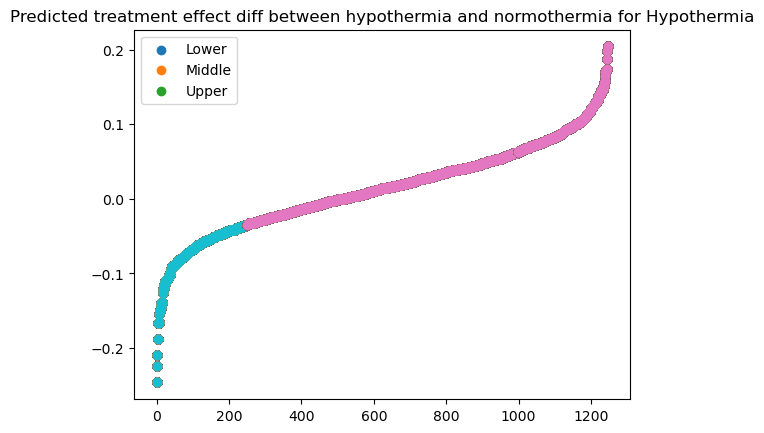

In [80]:
plotPredictedTreatmentEffect(myNewDf, 'Hypothermia')

In [15]:
def getTreatmentEffectDiff(X_train, y_train, myNewDf, aCategory = 'CPC12', aGroup = 'groupe'):
    if X_train.shape[0] != y_train.shape[0]:
        raise Exception('Mismatch X and Y')
    if X_train.shape[0] != myNewDf.shape[0]:
        raise Exception('Mismatch group and X')
    myData = pd.concat([X_train, myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)
    
    myPvaluesNoInteraction = model1.summary()
    myPvalues = model2.summary()

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'No interaction {myPvaluesNoInteraction}')
    print(f'Interaction {myPvalues}')
    return p_value
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import f

def getTreatmentEffectDiff_regression(X_train, y_train, myNewDf, aCategory='CPC12', aGroup='groupe'):
    # Combine the relevant data into one DataFrame
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    myData = myData.rename(columns={y_train.name: aCategory})  # Ensure the target column is named consistently

    # Fit the reduced model (without interaction term)
    model1 = smf.ols(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    # Fit the full model (with interaction term)
    model2 = smf.ols(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    # Perform an F-test to compare the models
    f_stat = (model1.ssr - model2.ssr) / (model2.df_model - model1.df_model) / (model2.ssr / model2.df_resid)
    df_diff = model2.df_model - model1.df_model
    p_value = f.sf(f_stat, df_diff, model2.df_resid)

    print(f'Likelihood ratio of test results (F-test for regression):')
    print(f'F-statistic: {f_stat}')
    print(f'p-value: {p_value}')
    print(f'Degrees of freedom: {df_diff}')
    return p_value


PatsyError: Error evaluating factor: NameError: name 'LastMGCSPositive' is not defined
    LastMGCSPositive ~ predicted_effect_group + gender
    ^^^^^^^^^^^^^^^^

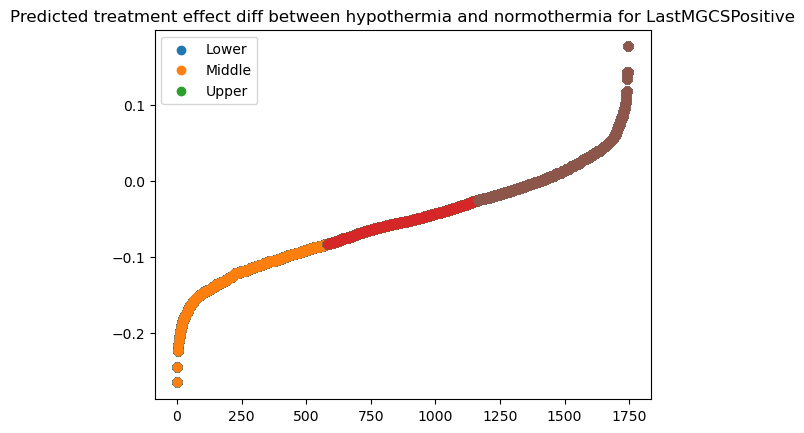

In [34]:
# getTreatmentEffectDiff_regression(X_train, myYValue, myNewDf, 'LastGCS', 'Hypothermia')
myNewXTest = myPipeline.transform(X_train_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect']
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, 'LastMGCSPositive')

# myNewDf['predicted_effect_group'] = CATE_pred[:, 0]


X_test_new = X_train_no_group.copy()
X_test_new['Hypothermia'] = T_train
getTreatmentEffectDiff(X_test_new, Y_train, myNewDf, 'LastMGCSPositive', 'gender')

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


-0.04229935943168943
0.042609285455865


PatsyError: Error evaluating factor: NameError: name 'DeathAtDischarge' is not defined
    DeathAtDischarge ~ predicted_effect_group + Hypothermia
    ^^^^^^^^^^^^^^^^

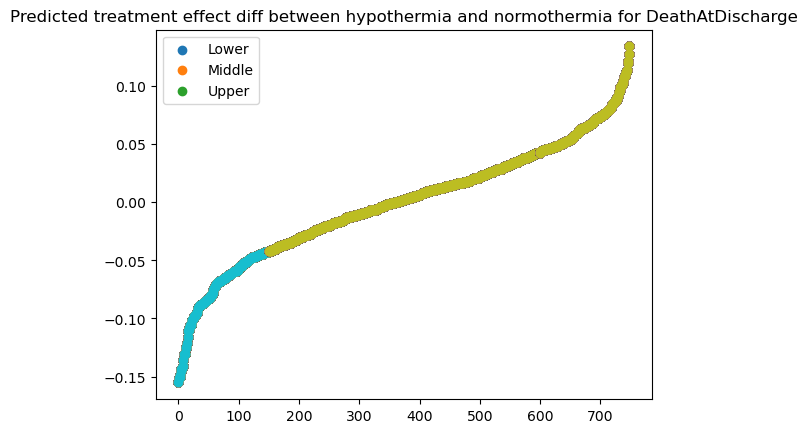

In [82]:
myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
# myNewDf['predicted_effect_group'] = 'Middle'
# myNewDf.loc[myNewDf['predicted_effect'] > upper_third, 'predicted_effect_group'] = 'Upper'
# myNewDf.loc[myNewDf['predicted_effect'] < lower_third, 'predicted_effect_group'] = 'Lower'
plotPredictedTreatmentEffect(myNewDf, 'DeathAtDischarge')

X_test_new = X_test_no_group.copy()
X_test_new['Hypothermia'] = T_test
getTreatmentEffectDiff(X_test_new, Y_test, myNewDf, 'DeathAtDischarge', 'Hypothermia')

In [33]:
def getPredictedThirds(aDf):
    lower_third = aDf['predicted_effect'].quantile(1/5)
    upper_third = aDf['predicted_effect'].quantile(4/5)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1, 1, aDf
    aDf['predicted_effect_group'] = pd.cut(
        aDf['predicted_effect'],
        bins=[-float('inf'), lower_third, upper_third, float('inf')],
        labels=['Lower', 'Middle', 'Upper']
    )
    # aDf['predicted_effect_group'] = (aDf['predicted_effect'] > 0).astype(int)
    print(lower_third)
    print(upper_third)
    return lower_third, upper_third, aDf

In [382]:
myXValue

,gender,age,admissionheight,admissionweight,PEA,Asystole,VTachy,VFib,Hypothermia,FirstGCS,FirstMGCS,Lactate,Troponin,pH,Chloride
116,0,57,154.90,54.70,0,0,0,0,0,9,5,1.6,NaN,7.470,100.0
117,0,48,177.80,99.00,0,1,0,0,0,15,6,1.6,NaN,NaN,105.0
119,0,50,167.60,110.20,0,0,0,1,1,9,4,1.3,0.26,7.300,102.0
120,0,24,167.64,74.69,0,0,0,0,0,3,1,6.6,NaN,7.257,105.0
121,0,63,165.10,92.90,0,1,0,0,0,11,4,NaN,NaN,7.484,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,0,64,160.00,85.60,0,0,0,1,0,14,6,NaN,27.72,7.419,105.0
3393,0,69,182.90,127.80,0,0,0,0,0,3,1,0.9,NaN,7.277,105.0
3395,0,42,185.40,110.90,0,1,0,0,0,3,1,2.3,0.04,6.879,95.0
3402,0,82,162.60,61.40,1,0,0,0,1,10,6,10.6,0.22,7.302,106.0
